# Построение межмолекулярного интерфейса
В решении задачи с электростатической комплементарностью нам чаще всего предлагают рассчитывать электростатическое поле в точках поверхности доступности растворителя обеих биомолекул (рис. 1а), но эта поверхность не в точности совпатадет для оцениваемых компонентов системы, образуя пустоты и наложения. Для задач визуализации и расчета разных вещей, связанных с межмолекулярными взаимодействиями, полезно уметь строить интерфейс между молекулами, который лишен этих недостатков и состоит из наиболее правдоподобных точек контакта (рис. 1б). В этой работе попробуем определить, что из себя должен представлять этот интерфейс и как его численно найти для конкретной системы.

![](images/interface-vs-sas.png)

## Постановка задачи
__Интерфейсом__ будем называть геометрическое место точек, равноудаленное по какой-либо метрике $\phi(\mathbf{r})$ от границ [выпуклой оболочки](https://en.wikipedia.org/wiki/Convex_hull) обеих подсистем (молекулы A и B), возможно, построенной с учетом радиусов атомов. По заданным координатам атомов нужно определить дискретную поверхность (набор полигонов), наиболее точно воспроизводящую интерфейс, то есть: 
$$
\begin{align}
S(\mathbf{r})&: \phi(\mathbf{r}) = 0 \\
\hat{S} &= \{\mathbf{r_i}\quad|\quad \mathbf{r_i} \in S\}
\end{align}
$$

В дальнейшем эту поверхность можно визуализировать или считать на ее узлах интересующие параметры системы, например, электронную плотность либо электростатический потенциал.

## 1. Простейший случай
Самая простая идея — разбить пространство по [Вороному](https://en.wikipedia.org/wiki/Voronoi_diagram), распределив атомы в соотвествующие ячейки и объединить их согласно молекулам, тогда граница между объединенными областями пространства и будет нашим интерфейсом.

В этом случае наша метрика будет вычисляться так
$$ \phi(\mathbf{r}) = \min\left\lVert\mathbf{r} - \mathbf{a}\right\rVert - \min\left\lVert\mathbf{r} - \mathbf{b}\right\rVert $$
где $\mathbf{a}$ и $\mathbf{b}$ — координаты атомов молекул A и B, $\mathbf{r}$ — координаты точки в пространстве. Такое поле еще называют [SDF](https://en.wikipedia.org/wiki/Signed_distance_function) (Signed Distance Field).

Для построения интерфейса мы можем на регулярной решетке вычислить значения SDF, а после этого найти изоповерхность, например, с помощью алгоритма [Marching Cubes](https://en.wikipedia.org/wiki/Marching_cubes).

Ниже попробуем это сделать

In [1]:
from copy import deepcopy
from pathlib import Path

import numpy as np
from scipy.spatial import cKDTree

from skimage import measure
import trimesh
from trimesh.smoothing import laplacian_calculation

import gemmi
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

### Читаем структуру

In [2]:
def read_mmcif_coordinates(
        data: Path,
) -> pd.DataFrame:
    """
    Читает координаты в первой модели в mmcif файле и отдает датафрейм с секцией атомных координат
    """
    structure_block = gemmi.cif.read_file(data.as_posix()).sole_block()
    atoms_table = structure_block.find_mmcif_category("_atom_site")
    df = pd.DataFrame(
        atoms_table,
        columns=map(lambda s: s.split(".")[-1], atoms_table.tags)
    )
    df["vdw"] = df.type_symbol.map(lambda s: gemmi.Element(s).vdw_r)
    return df

In [3]:
structure_3jrs = read_mmcif_coordinates(Path("data/3jrs.cif"))
structure_3jrs.head()

,group_PDB,id,type_symbol,label_atom_id,label_alt_id,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,Cartn_x,Cartn_y,Cartn_z,occupancy,B_iso_or_equiv,pdbx_formal_charge,auth_asym_id,pdbx_PDB_model_num,vdw
0,ATOM,1,N,N,.,SER,B,.,30,?,75.962,-8.306,38.982,1.00,39.29,0,B,1,1.55
1,ATOM,2,C,CA,.,SER,B,.,30,?,74.663,-7.736,38.503,1.00,39.20,0,B,1,1.70
2,ATOM,3,C,C,.,SER,B,.,30,?,73.467,-8.361,39.232,1.00,38.48,0,B,1,1.70
3,ATOM,4,O,O,.,SER,B,.,30,?,72.315,-8.108,38.883,1.00,37.45,0,B,1,1.52
4,ATOM,5,C,CB,.,SER,B,.,30,?,74.499,-7.926,36.983,1.00,39.98,0,B,1,1.70


### Выделяем подсистему

In [4]:
def extract_subsystems(
        system: pd.DataFrame,
        query_resnames: list[str],
) -> tuple[
        np.ndarray, # query_xyz[N, 3]
        np.ndarray, # query_vdw[N, 1]
        np.ndarray, # rest_xyz[N, 3]
        np.ndarray  # rest_vdw[N, 1]
]:
    query = system[system.label_comp_id.isin(query_resnames)]
    rest = system[~system.label_comp_id.isin(query_resnames)]
    coordinate_columns = ["Cartn_x", "Cartn_y", "Cartn_z"]
    
    query_xyz = np.asarray(query[coordinate_columns], dtype=np.float16)
    query_vdw = np.asarray(query.vdw)
    
    rest_xyz = np.asarray(rest[coordinate_columns], dtype=np.float16)
    rest_vdw = np.asarray(rest.vdw)

    return query_xyz, query_vdw, rest_xyz, rest_vdw

In [5]:
lig_xyz, lig_vdw, prot_xyz, prot_vdw = extract_subsystems(structure_3jrs, ["A8S"])

### Храним координаты атомов в KD-деревьях, чтобы быстрее находить соседей и считать расстояния

In [6]:
lig_kdtree = cKDTree(lig_xyz)
prot_kdtree = cKDTree(prot_xyz)

### Ограничиваем область интерфейса только атомами в пределах отсечения, в нашем случае — 6Å и делаем сетку

In [7]:
def find_neighbor_indexes(
        a_xyz: np.ndarray,
        b_xyz: np.ndarray,
        distance_threshold: float = 6.0,
) -> tuple[list[int]]:
    a_tree = cKDTree(a_xyz)
    b_tree = cKDTree(b_xyz)

    a_neighbors_idx = list({
        nbr
        for nbr_list in a_tree.query_ball_point(b_xyz, distance_threshold)
        for nbr in nbr_list
    })
    b_neighbors_idx = list({
        nbr
        for nbr_list in b_tree.query_ball_point(a_xyz, distance_threshold)
        for nbr in nbr_list
    })

    return a_neighbors_idx, b_neighbors_idx

In [8]:
def make_interface_grid(
        a_xyz: np.ndarray,
        b_xyz: np.ndarray,
        distance_threshold: float = 6.0,
        grid_padding: float = 0.0,
        grid_points_per_angstrom: int = 1,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    a_neighbors_idx, b_neighbors_idx = find_neighbor_indexes(
        a_xyz,
        b_xyz,
        distance_threshold,
    )
    
    interface_atoms = np.concatenate(
        [
            a_xyz[a_neighbors_idx],
            b_xyz[b_neighbors_idx],
        ],
        axis=0,
    )

    limits = [
        (
            np.min(interface_atoms.T[i]),  # dim_min
            np.max(interface_atoms.T[i]),  # dim_max
        )
        for i in range(3)
    ]

    grd_xx, grd_yy, grd_zz = np.meshgrid(
        *(
            np.linspace(
                d_min - grid_padding,
                d_max + grid_padding,
                grid_points_per_angstrom * np.ceil(d_max - d_min + 2 * grid_padding).astype(int)
            )
            for d_min, d_max in limits
        ),
        indexing='ij',
    ) 

    return grd_xx, grd_yy, grd_zz

In [9]:
%%time
grd_xx, grd_yy, grd_zz = make_interface_grid(lig_xyz, prot_xyz)

CPU times: user 6.67 ms, sys: 1.89 ms, total: 8.56 ms
Wall time: 9.52 ms


In [10]:
grd_xx.shape

(18, 19, 20)

### Нарисуем как выглядят интерфейсные атомы

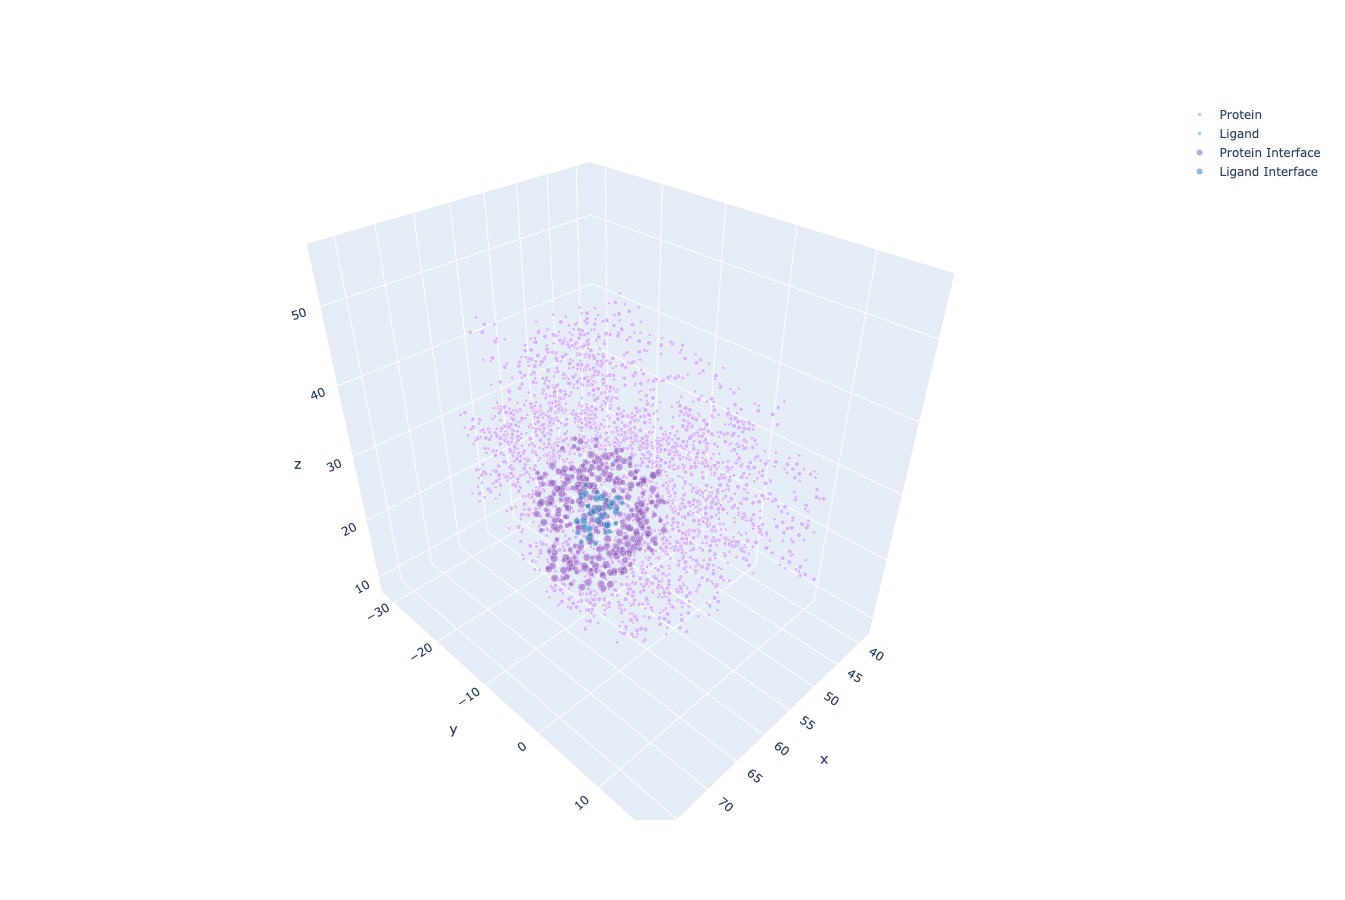

In [11]:
lig_neighbors_idx, prot_neighbors_idx = find_neighbor_indexes(
        lig_xyz,
        prot_xyz,
        6.0,
    )

prot_full = go.Scatter3d(
    x=prot_xyz.T[0],
    y=prot_xyz.T[1],
    z=prot_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#CD9EF7",
        size=prot_vdw*3,
    ),
    mode="markers",
    name="Protein",
)
lig_full = go.Scatter3d(
    x=lig_xyz.T[0],
    y=lig_xyz.T[1],
    z=lig_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#64BAFF",
        size=lig_vdw*3,
    ),
    mode="markers",
    name="Ligand",
)
prot_interface = go.Scatter3d(
    x=prot_xyz.T[0, prot_neighbors_idx],
    y=prot_xyz.T[1, prot_neighbors_idx],
    z=prot_xyz.T[2, prot_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#8A56B9",
        size=prot_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Protein Interface",
)
lig_interface = go.Scatter3d(
    x=lig_xyz.T[0, lig_neighbors_idx],
    y=lig_xyz.T[1, lig_neighbors_idx],
    z=lig_xyz.T[2, lig_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#317AB5",
        size=lig_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Ligand Interface",
)

fig = go.Figure(
    data=[
        prot_full,
        lig_full,
        prot_interface,
        lig_interface,
    ],
)
fig.update_layout(width=1200, height=900)
fig.show()

### Рассчитаем значения SDF в точках сетки

In [12]:
def calculate_sdf(
    a_xyz: np.ndarray,
    a_vdw: np.ndarray,
    b_xyz: np.ndarray,
    b_vdw: np.ndarray,
    *,
    distance_threshold: float = 6.0,
    grid_padding: float = 0.0,
    grid_points_per_angstrom: int = 1,
) -> np.ndarray:
    # вычисляем сетку
    grd_xx, grd_yy, grd_zz = make_interface_grid(a_xyz, b_xyz, distance_threshold, grid_padding, grid_points_per_angstrom)
    
    # Собираем координаты узлов сетки в плоский массив точек [N*M*K, 3]
    grid_points = np.c_[
        grd_xx.ravel(),
        grd_yy.ravel(),
        grd_zz.ravel(),
    ]

    # Храним координаты в виде KD-деревьев
    a_tree = cKDTree(a_xyz)
    b_tree = cKDTree(b_xyz)

    # Вычисляем расстояние до ближайших к точке сетки атомов и их индексы
    dist_a, idx_a = a_tree.query(grid_points)
    dist_b, idx_b = b_tree.query(grid_points)

    # Считаем SDF
    sdf_points = dist_a - a_vdw[idx_a] - dist_b + b_vdw[idx_b]
    sdf_tensor = sdf_points.reshape(grd_xx.shape)

    return sdf_tensor, grd_xx, grd_yy, grd_zz

In [13]:
%%time
sdf, grd_xx, grd_yy, grd_zz = calculate_sdf(
    lig_xyz,
    lig_vdw,
    prot_xyz,
    prot_vdw,
    grid_points_per_angstrom=2,
)

CPU times: user 101 ms, sys: 9.8 ms, total: 111 ms
Wall time: 134 ms


### Найдем изоповерхности в поле SDF

In [14]:
class SurfaceMesh(trimesh.base.Trimesh):
    """
        Класс для удобного хранения меша,
        чтобы не таскать несколько массивов
    """
    def __init__(self, vertices, faces, normales, values=None):
        if values is None:
            values = np.zeros(vertices.shape[0])
        super().__init__(
            vertices=vertices,
            faces=faces,
            face_normals=normales,
            vertex_attributes=dict(
                values=values
            )
        )

    @property
    def values(self):
        return self.vertex_attributes.get("values")
        

    @classmethod
    def from_sdf(
            cls: "SurfaceMesh",
            sdf: np.ndarray,
            grd_xx: np.ndarray,
            grd_yy: np.ndarray,
            grd_zz: np.ndarray,
    ) -> "SurfaceMesh":

        # Вычисление начала координат сетки и spacing
        origin = np.asarray([
            grd_xx[0, 0, 0],
            grd_yy[0, 0, 0],
            grd_zz[0, 0, 0],
        ])
        spacing = (
            grd_xx[1, 0, 0] - grd_xx[0, 0, 0],
            grd_yy[0, 1, 0] - grd_yy[0, 0, 0],
            grd_zz[0, 0, 1] - grd_zz[0, 0, 0],
        )


        # Получение меша 
        verts, faces, normals, values = measure.marching_cubes(sdf, level=0, spacing=spacing)

        # Сдвиг вершин на origin
        verts_physical = verts + origin

        # Обработка нормалей
        # Нормали уже в физическом пространстве, но могут нуждаться в перенормировке
        # если spacing анизотропный (разные в разных направлениях)
        normals_physical = normals / np.linalg.norm(normals, axis=1, keepdims=True)
    
        return cls(verts_physical, faces, normals_physical)

In [15]:
mesh = SurfaceMesh.from_sdf(sdf, grd_xx, grd_yy, grd_zz)

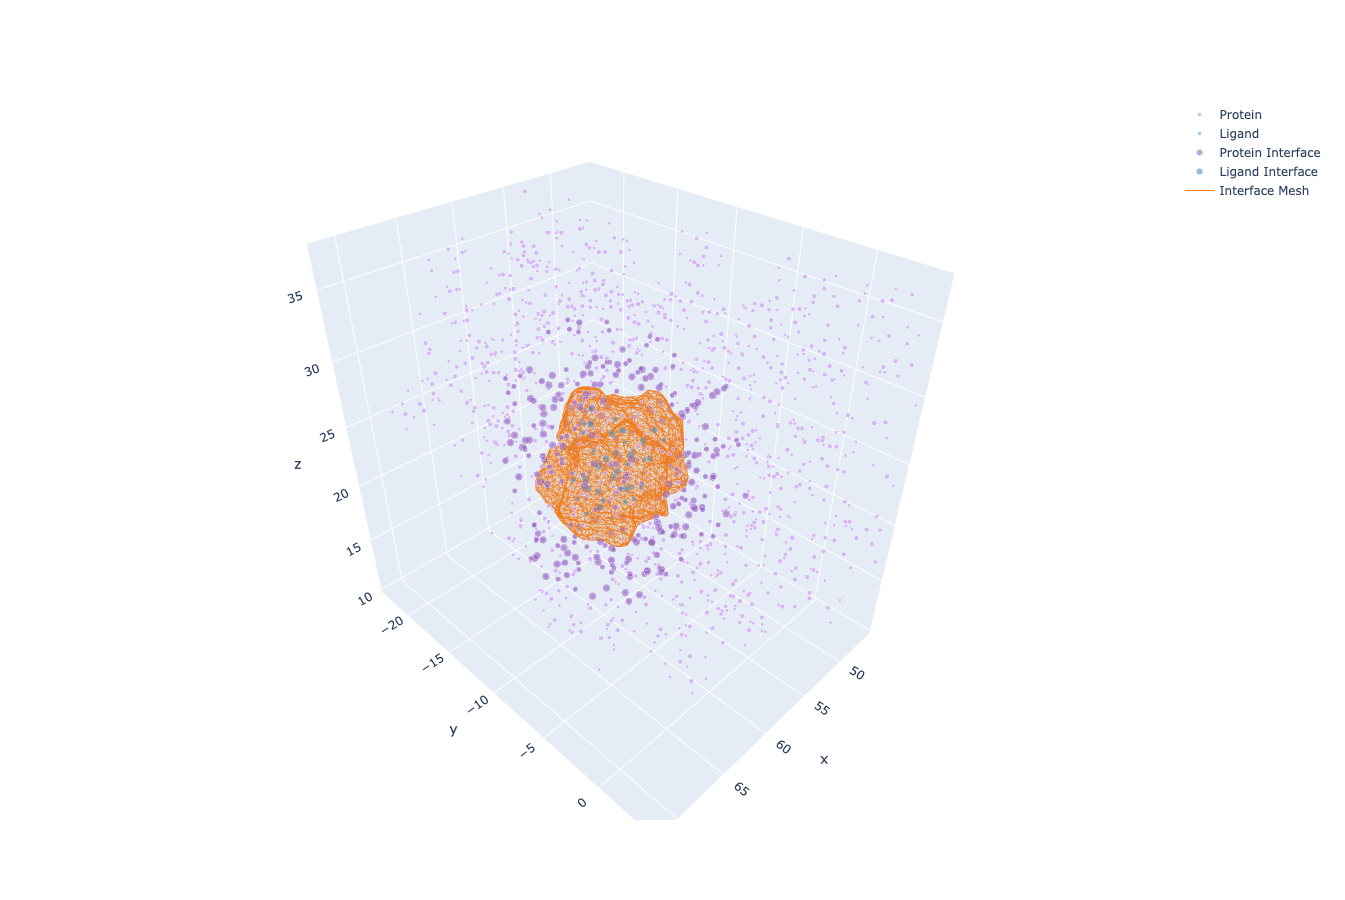

In [16]:
lig_neighbors_idx, prot_neighbors_idx = find_neighbor_indexes(
        lig_xyz,
        prot_xyz,
        6.0,
    )

prot_full = go.Scatter3d(
    x=prot_xyz.T[0],
    y=prot_xyz.T[1],
    z=prot_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#CD9EF7",
        size=prot_vdw*3,
    ),
    mode="markers",
    name="Protein",
)
lig_full = go.Scatter3d(
    x=lig_xyz.T[0],
    y=lig_xyz.T[1],
    z=lig_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#64BAFF",
        size=lig_vdw*3,
    ),
    mode="markers",
    name="Ligand",
)
prot_interface = go.Scatter3d(
    x=prot_xyz.T[0, prot_neighbors_idx],
    y=prot_xyz.T[1, prot_neighbors_idx],
    z=prot_xyz.T[2, prot_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#8A56B9",
        size=prot_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Protein Interface",
)
lig_interface = go.Scatter3d(
    x=lig_xyz.T[0, lig_neighbors_idx],
    y=lig_xyz.T[1, lig_neighbors_idx],
    z=lig_xyz.T[2, lig_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#317AB5",
        size=lig_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Ligand Interface",
)
interface = go.Mesh3d(
    x=mesh.vertices.T[0],
    y=mesh.vertices.T[1],
    z=mesh.vertices.T[2],
    i=mesh.faces.T[0],
    j=mesh.faces.T[1],
    k=mesh.faces.T[2],
    opacity=0.1,
    flatshading=True,
    color="#FFA154",
    name="Interface",
)

x_edges, y_edges, z_edges = [], [], []
for face in mesh.faces:
    for i in range(3):
        v0, v1 = face[i], face[(i+1)%3]
        x_edges.extend([mesh.vertices[v0,0], mesh.vertices[v1,0], None])
        y_edges.extend([mesh.vertices[v0,1], mesh.vertices[v1,1], None])
        z_edges.extend([mesh.vertices[v0,2], mesh.vertices[v1,2], None])

grid = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='#F47B18', width=1),
    hoverinfo='skip',
    name="Interface Mesh",
)

fig = go.Figure(
    data=[
        prot_full,
        lig_full,
        prot_interface,
        lig_interface,
        interface,
        grid,
        
    ],
)

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis=dict(range=[lig_xyz.T[0].min() - 10, lig_xyz.T[0].max() + 10]),
        yaxis=dict(range=[lig_xyz.T[1].min() - 10, lig_xyz.T[1].max() + 10]),
        zaxis=dict(range=[lig_xyz.T[2].min() - 10, lig_xyz.T[2].max() + 10]),
        aspectmode='data'  # Кубические пропорции — иногда помогает
    )

)
fig.show()

### Экспорт SDF для визуализации в Pymol

In [17]:
def export_to_pymol(
    sdf: np.ndarray,
    grd_xx: np.ndarray,
    grd_yy: np.ndarray,
    grd_zz: np.ndarray,
    file: Path,
):
    """
    Export scalar grid to PyMOL-compatible OpenDX format.
    
    Parameters
    ----------
    grid : np.ndarray of shape (nx, ny, nz)
        Your scalar density field
    origin : tuple (x, y, z)
        Physical coordinates of grid point (0, 0, 0)
    spacing : tuple (dx, dy, dz)
        Grid spacing in Angstroms (or any unit PyMOL uses)
    """
    # Вычисление начала координат сетки и spacing
    origin = (
        grd_xx[0, 0, 0],
        grd_yy[0, 0, 0],
        grd_zz[0, 0, 0],
    )
    spacing = (
        grd_xx[1, 0, 0] - grd_xx[0, 0, 0],
        grd_yy[0, 1, 0] - grd_yy[0, 0, 0],
        grd_zz[0, 0, 1] - grd_zz[0, 0, 0],
    )
    nx, ny, nz = sdf.shape

    file.parent.mkdir(exist_ok=True, parents=True)
    
    with file.open("w") as f:
        # Header defining the grid geometry
        f.write(f'object 1 class gridpositions counts {nx} {ny} {nz}\n')
        f.write(f'origin {origin[0]} {origin[1]} {origin[2]}\n')
        f.write(f'delta {spacing[0]} 0 0\n')
        f.write(f'delta 0 {spacing[1]} 0\n')
        f.write(f'delta 0 0 {spacing[2]}\n')
        f.write(f'object 2 class gridconnections counts {nx} {ny} {nz}\n')
        f.write(f'object 3 class array type float rank 0 items {nx*ny*nz} data follows\n')
        
        # Write data (Fortran order: x varies fastest)
        # This matches OpenDX expectation: grid[i,j,k] with i (x-index) changing fastest
        for val in sdf.ravel(order='C'):
            f.write(f'{val:.6e}\n')
            
        f.write(f'object "density" class field\n')

In [18]:
export_to_pymol(sdf, grd_xx, grd_yy, grd_zz, Path("data") / "3jrs_sdf.dx")

В итоге получаем поверхность с достаточно плоскими гранями, которая явно не гладкая, у этого есть ряд минусов:
 - выглядит не так красиво как гладкая молекулярная поверхность, например, SAS
 - на ребрах потенциалы будут сильно отличаться от того, что на плоскостях, может давать артефакты

![](images/simple-sdf-mc.png)

## Сглаживаем метрику взаимного расстояния
Нашу SDF можно сгладить, чтобы получить более красивый и удобный для дальнейших расчетов интерфейс. Для этого можно перейти от метрики
$\phi(\mathbf{r}) = \min\left\lVert\mathbf{r} - \mathbf{a}\right\rVert - \min\left\lVert\mathbf{r} - \mathbf{b}\right\rVert$ к более гладкой:
$$
\begin{align}
\phi(\mathbf{r}) &= \ln\sum_{i \in A} \exp\left(-\alpha\left(\left\lVert\mathbf{r} - \mathbf{a}_i\right\rVert^2 - r_{vdw_{i}}^2 \right)\right) \\
&- \ln\sum_{i \in B} \exp\left(-\alpha\left(\left\lVert\mathbf{r} - \mathbf{b}_i\right\rVert^2 - r_{vdw_{i}}^2 \right)\right)
\end{align}
$$

В таком случае бонусом мы получаем неограниченную дифференцируемость этого поля, что в дальнейшем нам может помочь в поиске более точного, чем Marching Cubes решения.

### Попробуем построить поверхность с учетом нового поля

In [19]:
def calculate_smooth_sdf(
    a_xyz: np.ndarray,
    a_vdw: np.ndarray,
    b_xyz: np.ndarray,
    b_vdw: np.ndarray,
    *,
    distance_threshold: float = 6.0,
    grid_padding: float = 0.0,
    grid_points_per_angstrom: int = 1,
    cutoff_radius: float = 5.0,
    smooth_factor: float = 1.5,
) -> np.ndarray:
    # вычисляем сетку
    grd_xx, grd_yy, grd_zz = make_interface_grid(a_xyz, b_xyz, distance_threshold, grid_padding, grid_points_per_angstrom)
    
    # Собираем координаты узлов сетки в плоский массив точек [N*M*K, 3]
    grid_points = np.c_[
        grd_xx.ravel(),
        grd_yy.ravel(),
        grd_zz.ravel(),
    ]
    grid_tree = cKDTree(grid_points)

    # Храним координаты в виде KD-деревьев
    a_tree = cKDTree(a_xyz)
    b_tree = cKDTree(b_xyz)

    # Вычисляем расстояние до ближайших к точке сетки атомов и их индексы
    # Работаем с разреженной матрицей расстояний (формат COO)
    # i — индексы grid_xyz, j — индексы атомов
    a_sparse_dist = grid_tree.sparse_distance_matrix(a_tree, cutoff_radius, output_type='coo_matrix')
        # sparse_dist.data — это уже вычисленные расстояния d = |G - P|
        # sparse_dist.row — индексы точек сетки (i)
        # sparse_dist.col — индексы атомов (j)
    a_d_squared = np.power(a_sparse_dist.data, 2)
    a_vdw_squared = np.power(a_vdw[a_sparse_dist.col], 2) # сопоставляем vdw по индексам
    a_exp_values = np.exp(-smooth_factor * (a_d_squared - a_vdw_squared))
        # Агрегируем значения обратно по строкам (по точкам сетки)
        # Используем np.bincount, это быстрее, чем преобразование в CSR и sum(axis=1)
    a_grid_sums = np.bincount(a_sparse_dist.row, weights=a_exp_values, minlength=len(grid_points))

    b_sparse_dist = grid_tree.sparse_distance_matrix(b_tree, cutoff_radius, output_type='coo_matrix')
    b_d_squared = np.power(b_sparse_dist.data, 2)
    b_vdw_squared = np.power(b_vdw[b_sparse_dist.col], 2) # сопоставляем vdw по индексам
    b_exp_values = np.exp(-smooth_factor * (b_d_squared - b_vdw_squared))
    b_grid_sums = np.bincount(b_sparse_dist.row, weights=b_exp_values, minlength=len(grid_points))
    
    # Считаем SDF
    sdf_points = np.log(a_grid_sums + 1e-5) - np.log(b_grid_sums + 1e-5)
    sdf_tensor = sdf_points.reshape(grd_xx.shape)

    return sdf_tensor, grd_xx, grd_yy, grd_zz

In [20]:
%%time
smooth_sdf, grd_xx, grd_yy, grd_zz = calculate_smooth_sdf(
    lig_xyz, lig_vdw,
    prot_xyz, prot_vdw,
    grid_points_per_angstrom=1,
    smooth_factor=0.5,
    cutoff_radius=5.0,
)

CPU times: user 49.4 ms, sys: 16.8 ms, total: 66.2 ms
Wall time: 76.8 ms


In [21]:
export_to_pymol(smooth_sdf, grd_xx, grd_yy, grd_zz, Path("data") / "3jrs_smooth_sdf.dx")

In [22]:
smooth_mesh = SurfaceMesh.from_sdf(smooth_sdf, grd_xx, grd_yy, grd_zz)
smooth_mesh

<trimesh.SurfaceMesh(vertices.shape=(422, 3), faces.shape=(840, 3))>

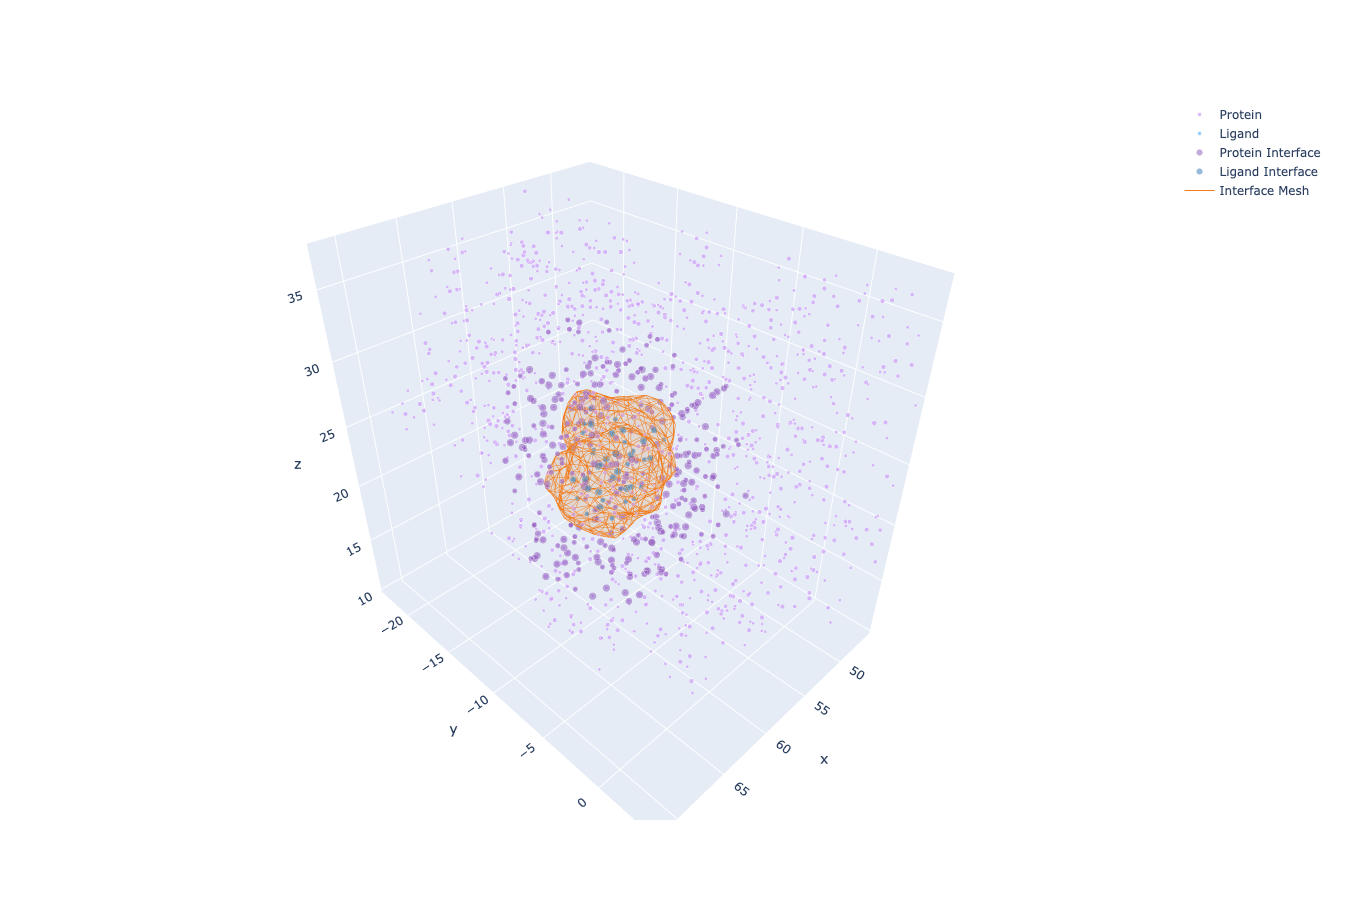

In [23]:
lig_neighbors_idx, prot_neighbors_idx = find_neighbor_indexes(
        lig_xyz,
        prot_xyz,
        6.0,
    )

prot_full = go.Scatter3d(
    x=prot_xyz.T[0],
    y=prot_xyz.T[1],
    z=prot_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#CD9EF7",
        size=prot_vdw*3,
    ),
    mode="markers",
    name="Protein",
)
lig_full = go.Scatter3d(
    x=lig_xyz.T[0],
    y=lig_xyz.T[1],
    z=lig_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#64BAFF",
        size=lig_vdw*3,
    ),
    mode="markers",
    name="Ligand",
)
prot_interface = go.Scatter3d(
    x=prot_xyz.T[0, prot_neighbors_idx],
    y=prot_xyz.T[1, prot_neighbors_idx],
    z=prot_xyz.T[2, prot_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#8A56B9",
        size=prot_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Protein Interface",
)
lig_interface = go.Scatter3d(
    x=lig_xyz.T[0, lig_neighbors_idx],
    y=lig_xyz.T[1, lig_neighbors_idx],
    z=lig_xyz.T[2, lig_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#317AB5",
        size=lig_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Ligand Interface",
)
interface = go.Mesh3d(
    x=smooth_mesh.vertices.T[0],
    y=smooth_mesh.vertices.T[1],
    z=smooth_mesh.vertices.T[2],
    i=smooth_mesh.faces.T[0],
    j=smooth_mesh.faces.T[1],
    k=smooth_mesh.faces.T[2],
    opacity=0.1,
    flatshading=True,
    color="#FFA154",
    name="Interface",
)

x_edges, y_edges, z_edges = [], [], []
for face in smooth_mesh.faces:
    for i in range(3):
        v0, v1 = face[i], face[(i+1)%3]
        x_edges.extend([smooth_mesh.vertices[v0,0], smooth_mesh.vertices[v1,0], None])
        y_edges.extend([smooth_mesh.vertices[v0,1], smooth_mesh.vertices[v1,1], None])
        z_edges.extend([smooth_mesh.vertices[v0,2], smooth_mesh.vertices[v1,2], None])

grid = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='#F47B18', width=1),
    hoverinfo='skip',
    name="Interface Mesh",
)

fig = go.Figure(
    data=[
        prot_full,
        lig_full,
        prot_interface,
        lig_interface,
        interface,
        grid,
        
    ],
)

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis=dict(range=[lig_xyz.T[0].min() - 10, lig_xyz.T[0].max() + 10]),
        yaxis=dict(range=[lig_xyz.T[1].min() - 10, lig_xyz.T[1].max() + 10]),
        zaxis=dict(range=[lig_xyz.T[2].min() - 10, lig_xyz.T[2].max() + 10]),
        aspectmode='data'  # Кубические пропорции — иногда помогает
    )

)
fig.show()

В итоге получаем существенно более гладкую поверхность, за не очень большой проигрыш по скорости

![](images/smooth-sdf-mc.png)

Сравнение поверхностей в Pymol (а) — простое SDF, (б) — гладкое SDF
![](images/interfaces-pymol.png)

## Дальнейшая оптимизация
Так как мы получили скалярное поле, для которого без труда можем рассчитать аналитический градиент, мы просто не можем себе позволить не решить задачу по оптимизации полученного меша. В нашем случае речь идет о минимизации площади поверхности одновременно с ее приближением к SDF=0. В терминах вариационного исчисления задачу можно выразить так:
$$
\begin{align}
J\left(S\right) &= \int_S dS &&\text{минимизация площади/кривизны}\\
&+ \lambda\int_S\left\vert\phi\left(\mathbf{r}\right)\right\vert^2 dS &&\text{минимизация отклонения}~\phi~{от}~0 \\
&\longrightarrow\min
\end{align}
$$

### Градиент SDF
$\phi(\mathbf{r})$ достаточно просто продифференцировать
$$
\begin{align}
f_A(\mathbf{r}) &= \sum_{i \in A} \exp\left(-\alpha\left(\left\lVert\mathbf{r} - \mathbf{a}_i\right\rVert^2 - r_{vdw_{i}}^2 \right)\right) \\
f_B(\mathbf{r}) &= \sum_{i \in B} \exp\left(-\alpha\left(\left\lVert\mathbf{r} - \mathbf{b}_i\right\rVert^2 - r_{vdw_{i}}^2 \right)\right) \\
\nabla\phi(\mathbf{r}) &= \frac{\nabla f_A(\mathbf{r})}{f_A(\mathbf{r})} - \frac{\nabla f_B(\mathbf{r})}{f_B(\mathbf{r})} \\
\nabla f_X(\mathbf{r}) &= -2\alpha\sum_i \left(\mathbf{r} - \mathbf{x}_i\right)\exp\left(-\alpha\left(\left\lVert\mathbf{r} - \mathbf{x}_i\right\rVert^2 - r_{vdw_{i}}^2 \right)\right) \\
\end{align}
$$

### Уравнение Эйлера-Лагранжа
Вооружившись полем и градиентом, мы можем приступить к решению вариационной задачей, для этого сведем ее к уравнению Эйлера-Лагранжа
$$
\begin{align}
\frac{\partial\mathbf{v}_i}{\partial t} &= \omega_s\mathbf{L}(\mathbf{v}_i) + \omega_d\mathbf{F_\mathrm{ext}}(\mathbf{v}_i) \\
&~ \\
\mathbf{L}(\mathbf{v}_i) &= \frac{1}{\left\vert N_i\right\vert} \sum_{j \in N_i} \left(\mathbf{v}_j - \mathbf{v}_i\right) \\
\mathbf{F_\mathrm{ext}}(\mathbf{v}_i) &= -\phi(\mathbf{v}_i) \frac{\nabla\phi(\mathbf{v}_i)}{\left\Vert\nabla\phi(\mathbf{v}_i)\right\Vert^2}
\end{align}
$$

где 
 - $\mathbf{v}_i$ — координаты вершины оптимизируемого меша,
 - $\omega$ - весовые коэффициенты, определяющие баланс между гладкостью и точностью
 - $\mathbf{L}(\mathbf{v}_i)$ — сглаживающий оператор Лапласа-Бельтрами, минимизирует кривизну
 - $N_i$ — вершины, соседние с $i$, $\left\vert N_i\right\vert$ — степень вершины
 - $\mathbf{F_\mathrm{ext}}(\mathbf{v}_i)$ — сила «притяжения» поверхности к данным

Это уравнение будем решать методом градиентного спуска, с начальным условием в виде меша, полученного на предыдущем шаге

In [28]:
class InterfaceMeshOptimizer:
    def __init__(
        self,
        a_xyz: np.ndarray,
        a_vdw: np.ndarray,
        b_xyz: np.ndarray,
        b_vdw: np.ndarray,
        *,
        cutoff_radius: float = 5.0,
        smooth_factor: float = 0.5,
    ):
        self.a_xyz = a_xyz
        self.a_vdw = a_vdw
        self.b_xyz = b_xyz
        self.b_vdw = b_vdw
        self.cutoff_radius = cutoff_radius
        self.smooth_factor = smooth_factor


    def calculate_mesh_field_grad(self, mesh: SurfaceMesh) -> tuple[np.ndarray, np.ndarray]:
        a_tree = cKDTree(self.a_xyz)
        b_tree = cKDTree(self.b_xyz)
        mesh_tree = cKDTree(mesh.vertices)
        
        a_sparse_dist = mesh_tree.sparse_distance_matrix(a_tree, self.cutoff_radius, output_type='coo_matrix')
        a_d_squared = np.power(a_sparse_dist.data, 2)
        a_vdw_squared = np.power(self.a_vdw[a_sparse_dist.col], 2)
        a_exp_values = np.exp(-self.smooth_factor * (a_d_squared - a_vdw_squared))
        a_diff_vectors = mesh.vertices[a_sparse_dist.row] - self.a_xyz[a_sparse_dist.col]
        a_grid_sums = np.bincount(a_sparse_dist.row, weights=a_exp_values, minlength=len(mesh.vertices))
        # Элементы градиента
        a_diff_vectors = mesh.vertices[a_sparse_dist.row] - self.a_xyz[a_sparse_dist.col]
        a_grad_contributions = -2 * self.smooth_factor * a_diff_vectors * a_exp_values[:, np.newaxis] 

        b_sparse_dist = mesh_tree.sparse_distance_matrix(b_tree, self.cutoff_radius, output_type='coo_matrix')
        b_d_squared = np.power(b_sparse_dist.data, 2)
        b_vdw_squared = np.power(self.b_vdw[b_sparse_dist.col], 2)
        b_exp_values = np.exp(-self.smooth_factor * (b_d_squared - b_vdw_squared))
        b_grid_sums = np.bincount(b_sparse_dist.row, weights=b_exp_values, minlength=len(mesh.vertices))

        b_diff_vectors = mesh.vertices[b_sparse_dist.row] - self.b_xyz[b_sparse_dist.col]
        b_grad_contributions = -2 * self.smooth_factor * b_diff_vectors * b_exp_values[:, np.newaxis]
        
        field = np.log(a_grid_sums + 1e-9) - np.log(b_grid_sums + 1e-9)

        # Собираем градиент
        gradient = np.zeros_like(mesh.vertices)
        for dim in range(3):
            gradient[:, dim] = np.bincount(
                a_sparse_dist.row,
                weights=a_grad_contributions[:, dim],
                minlength=len(mesh.vertices)
            ) / (a_grid_sums + 1e-9) - \
            np.bincount(
                b_sparse_dist.row,
                weights=b_grad_contributions[:, dim],
                minlength=len(mesh.vertices)
            ) / (b_grid_sums + 1e-9)
            
        return field, gradient

    def evolve(self, mesh, iterations=50, dt=0.05, smoothing=0.005):
        mesh_ = deepcopy(mesh)
        mean_edge_length = np.mean(mesh_.edges_unique_length)
        """Основной цикл Эйлера-Лагранжа для вершин меша"""
        for i in range(iterations):
            l_matrix = laplacian_calculation(mesh_, equal_weight=False)
            v = mesh_.vertices
            
            # 1. Внутренняя сила (Лапласиан / Smoothing)
            # Используем встроенный в trimesh оператор для скорости
            l_force = l_matrix.dot(v)
            
            # 2. Внешняя сила (Аналитический градиент интерфейса)
            f_val, f_grad = self.calculate_mesh_field_grad(mesh_)
                        
            # Нормализуем градиент, чтобы шаг был стабильным
            gnorm = np.linalg.norm(f_grad, axis=1, keepdims=True) + 1e-9
            f_external = -(f_val[:, None] * f_grad) / gnorm

            print(
                "wL =", smoothing*np.mean(np.linalg.norm(l_force, axis=1)),
                "F =", np.mean(np.linalg.norm(f_external, axis=1)),
                "Total =", np.mean(np.linalg.norm(smoothing * l_force + f_external, axis=1)),
            )
            # 3. Шаг обновления
            new_v = v + dt * (smoothing * l_force + f_external)
            # Проверка сходимости
            shift = np.mean(np.linalg.norm(new_v - v, axis=1))
            mesh_.vertices = new_v
            
            if shift < 1e-4:
                print(f"Converged at iter {i}")
                break
        return mesh_

In [29]:
iop = InterfaceMeshOptimizer(lig_xyz, lig_vdw, prot_xyz, prot_vdw)

In [30]:
smoother_mesh = iop.evolve(smooth_mesh, iterations=200, dt=0.05, smoothing=0.00001)

wL = 0.000644333603589916 F = 0.11336954275687802 Total = 0.11351718210716748
wL = 0.0006443508723779697 F = 0.09669980938429854 Total = 0.0968480189056603
wL = 0.0006443655357741624 F = 0.08249097725730105 Total = 0.08263986768356155
wL = 0.0006443779926452282 F = 0.07038026796979921 Total = 0.0705299620187014
wL = 0.0006443885809265564 F = 0.06005807971234271 Total = 0.06020871359103775
wL = 0.000644397586520601 F = 0.05125915895444804 Total = 0.05141088519558576
wL = 0.0006444052515619917 F = 0.04375893346567989 Total = 0.04391186083758159
wL = 0.0006444117812699422 F = 0.037364104850925776 Total = 0.03751822102929903
wL = 0.0006444173491179762 F = 0.03191123991397988 Total = 0.03206640703556434
wL = 0.0006444221021234335 F = 0.027260168339511948 Total = 0.02741673297598794
wL = 0.0006444261647731934 F = 0.023292146050927408 Total = 0.023450475586549734
wL = 0.0006444296424062948 F = 0.0199057799912783 Total = 0.020066268642330784
wL = 0.0006444326242417157 F = 0.017015486170465936 

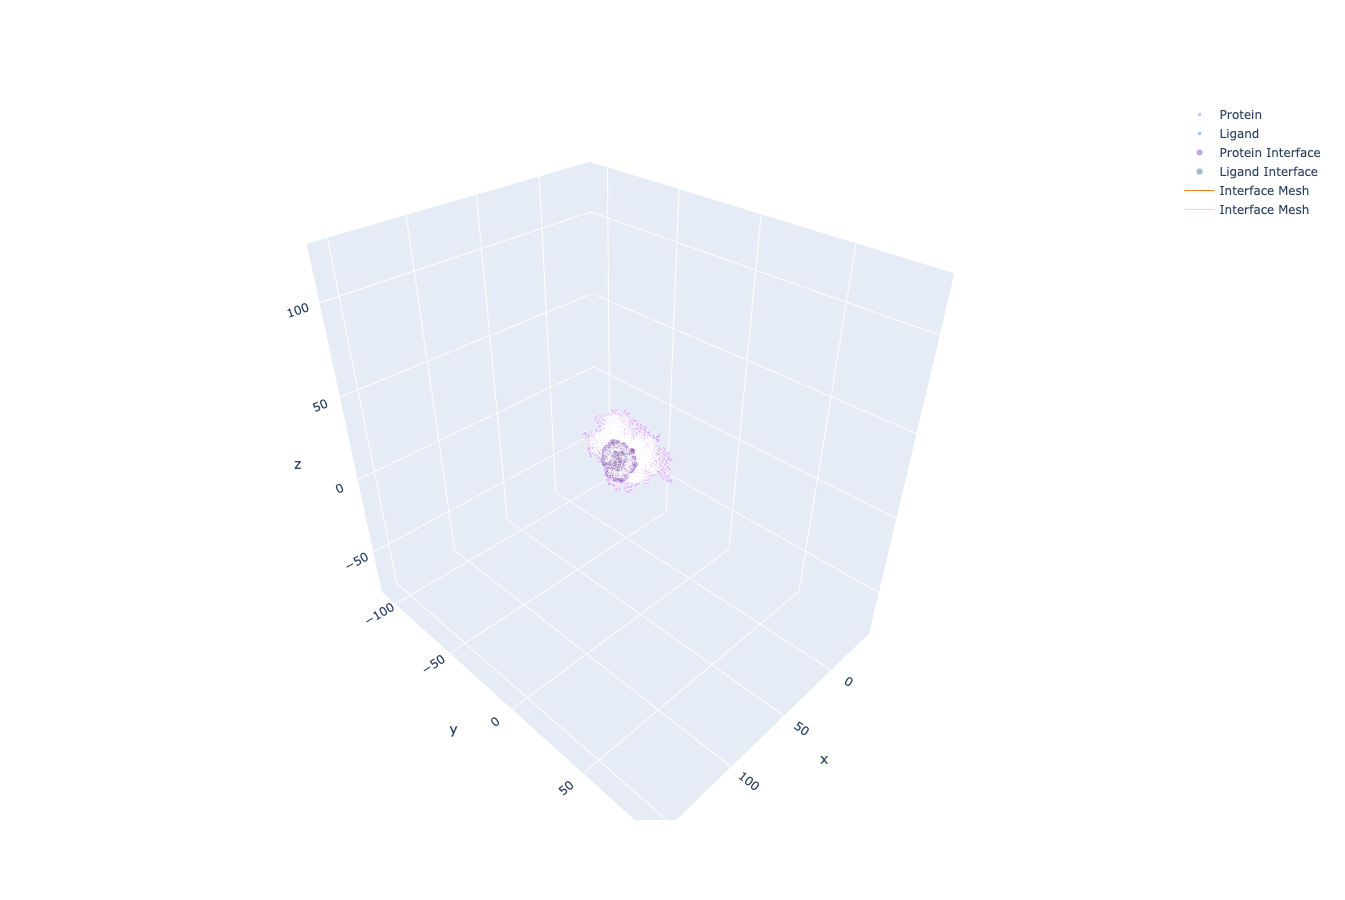

In [31]:
lig_neighbors_idx, prot_neighbors_idx = find_neighbor_indexes(
        lig_xyz,
        prot_xyz,
        6.0,
    )

prot_full = go.Scatter3d(
    x=prot_xyz.T[0],
    y=prot_xyz.T[1],
    z=prot_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#CD9EF7",
        size=prot_vdw*3,
    ),
    mode="markers",
    name="Protein",
)
lig_full = go.Scatter3d(
    x=lig_xyz.T[0],
    y=lig_xyz.T[1],
    z=lig_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#64BAFF",
        size=lig_vdw*3,
    ),
    mode="markers",
    name="Ligand",
)
prot_interface = go.Scatter3d(
    x=prot_xyz.T[0, prot_neighbors_idx],
    y=prot_xyz.T[1, prot_neighbors_idx],
    z=prot_xyz.T[2, prot_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#8A56B9",
        size=prot_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Protein Interface",
)
lig_interface = go.Scatter3d(
    x=lig_xyz.T[0, lig_neighbors_idx],
    y=lig_xyz.T[1, lig_neighbors_idx],
    z=lig_xyz.T[2, lig_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#317AB5",
        size=lig_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Ligand Interface",
)
interface = go.Mesh3d(
    x=smooth_mesh.vertices.T[0],
    y=smooth_mesh.vertices.T[1],
    z=smooth_mesh.vertices.T[2],
    i=smooth_mesh.faces.T[0],
    j=smooth_mesh.faces.T[1],
    k=smooth_mesh.faces.T[2],
    opacity=0.1,
    flatshading=True,
    color="#FFA154",
    name="Interface",
)

interface2 = go.Mesh3d(
    x=smoother_mesh.vertices.T[0],
    y=smoother_mesh.vertices.T[1],
    z=smoother_mesh.vertices.T[2],
    i=smoother_mesh.faces.T[0],
    j=smoother_mesh.faces.T[1],
    k=smoother_mesh.faces.T[2],
    opacity=0.2,
    flatshading=True,
    color="#FFFF54",
    name="Interface",
)

x_edges, y_edges, z_edges = [], [], []
for face in smooth_mesh.faces:
    for i in range(3):
        v0, v1 = face[i], face[(i+1)%3]
        x_edges.extend([smooth_mesh.vertices[v0,0], smooth_mesh.vertices[v1,0], None])
        y_edges.extend([smooth_mesh.vertices[v0,1], smooth_mesh.vertices[v1,1], None])
        z_edges.extend([smooth_mesh.vertices[v0,2], smooth_mesh.vertices[v1,2], None])

grid = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='#F47B18', width=1),
    hoverinfo='skip',
    name="Interface Mesh",
)
x_edges, y_edges, z_edges = [], [], []
for face in smoother_mesh.faces:
    for i in range(3):
        v0, v1 = face[i], face[(i+1)%3]
        x_edges.extend([smoother_mesh.vertices[v0,0], smoother_mesh.vertices[v1,0], None])
        y_edges.extend([smoother_mesh.vertices[v0,1], smoother_mesh.vertices[v1,1], None])
        z_edges.extend([smoother_mesh.vertices[v0,2], smoother_mesh.vertices[v1,2], None])

grid2 = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='#F4FF18', width=1),
    hoverinfo='skip',
    name="Interface Mesh",
)

fig = go.Figure(
    data=[
        prot_full,
        lig_full,
        prot_interface,
        lig_interface,
        interface,
        interface2,
        grid,
        grid2,
        
    ],
)

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis=dict(range=[lig_xyz.T[0].min() - 100, lig_xyz.T[0].max() + 100]),
        yaxis=dict(range=[lig_xyz.T[1].min() - 100, lig_xyz.T[1].max() + 100]),
        zaxis=dict(range=[lig_xyz.T[2].min() - 100, lig_xyz.T[2].max() + 100]),
        aspectmode='data'
    )

)
fig.show()

In [32]:
weird_mesh = iop.evolve(smooth_mesh, iterations=20, dt=0.05, smoothing=0.1)

wL = 6.44333603589916 F = 0.11336954275687802 Total = 6.479892836647094
wL = 6.47571896149638 F = 0.487924590183414 Total = 6.156286713210369
wL = 6.506495130210908 F = 0.9323583799405963 Total = 5.895801350998481
wL = 6.5358727847991105 F = 1.335860877469203 Total = 5.679921235280008
wL = 6.5639891371496155 F = 1.6937266357190277 Total = 5.501991899932318
wL = 6.590981603159806 F = 2.005592631187391 Total = 5.34962181723244
wL = 6.6169637796357 F = 2.285080266814185 Total = 5.210778934834972
wL = 6.6420111359433625 F = 2.538825383368935 Total = 5.083194163906398
wL = 6.666203069096818 F = 2.766517947647648 Total = 4.942314884662972
wL = 6.689459416033857 F = 2.975665555691844 Total = 4.787881812935967
wL = 6.711697969392269 F = 3.19569346715523 Total = 4.638872830359262
wL = 6.732961937523903 F = 3.417315115360797 Total = 4.504008118350596
wL = 6.753369747901456 F = 3.609404220232275 Total = 4.357116835409398
wL = 6.77288245408235 F = 3.7828354623615694 Total = 4.180369244645967
wL = 

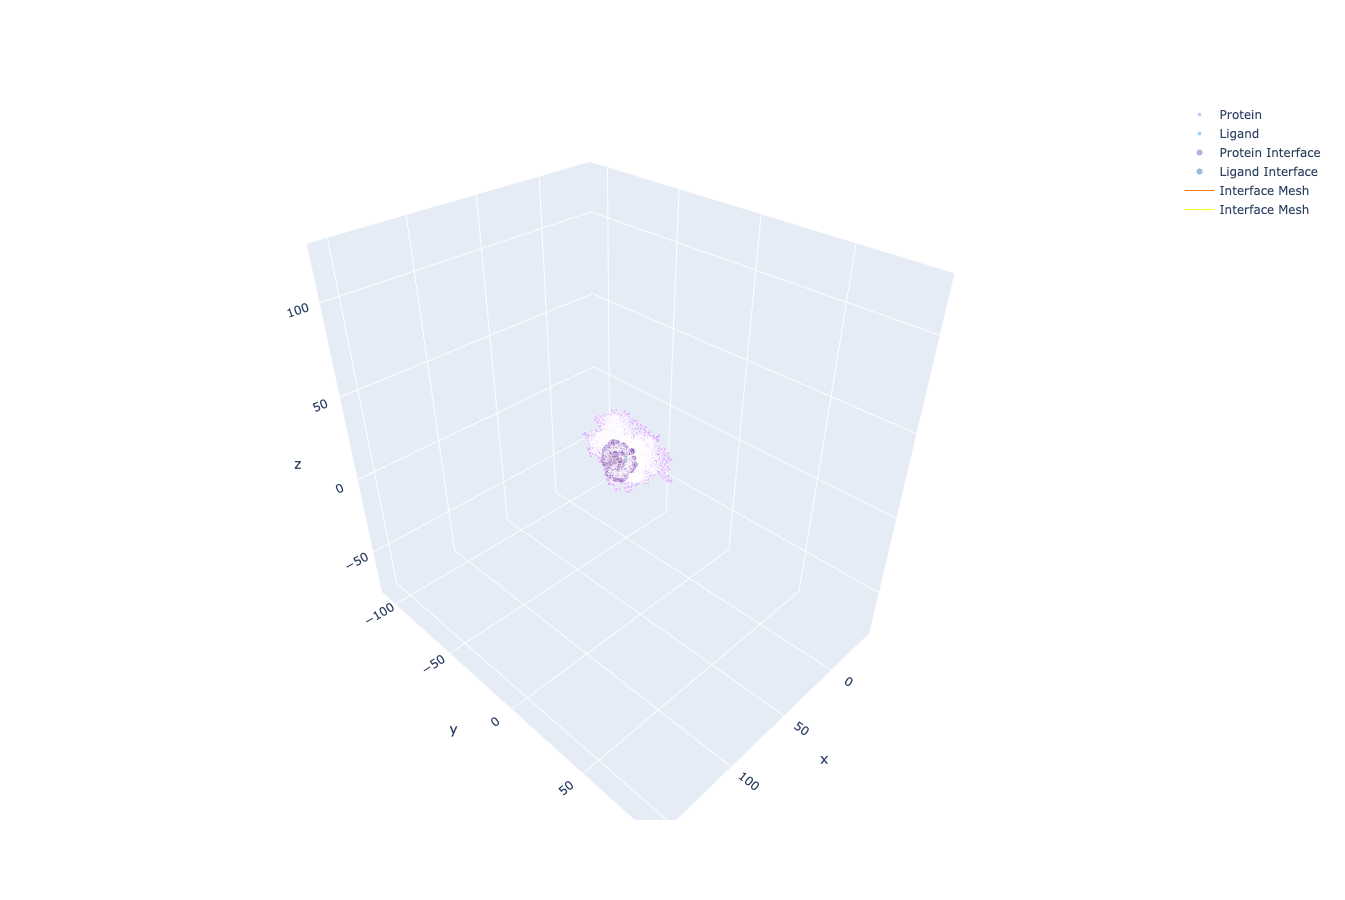

In [33]:
lig_neighbors_idx, prot_neighbors_idx = find_neighbor_indexes(
        lig_xyz,
        prot_xyz,
        6.0,
    )

prot_full = go.Scatter3d(
    x=prot_xyz.T[0],
    y=prot_xyz.T[1],
    z=prot_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#CD9EF7",
        size=prot_vdw*3,
    ),
    mode="markers",
    name="Protein",
)
lig_full = go.Scatter3d(
    x=lig_xyz.T[0],
    y=lig_xyz.T[1],
    z=lig_xyz.T[2],
    marker=go.scatter3d.Marker(
        color="#64BAFF",
        size=lig_vdw*3,
    ),
    mode="markers",
    name="Ligand",
)
prot_interface = go.Scatter3d(
    x=prot_xyz.T[0, prot_neighbors_idx],
    y=prot_xyz.T[1, prot_neighbors_idx],
    z=prot_xyz.T[2, prot_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#8A56B9",
        size=prot_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Protein Interface",
)
lig_interface = go.Scatter3d(
    x=lig_xyz.T[0, lig_neighbors_idx],
    y=lig_xyz.T[1, lig_neighbors_idx],
    z=lig_xyz.T[2, lig_neighbors_idx],
    marker=go.scatter3d.Marker(
        color="#317AB5",
        size=lig_vdw*5,
        opacity=0.5,
    ),
    mode="markers",
    name="Ligand Interface",
)
interface = go.Mesh3d(
    x=smooth_mesh.vertices.T[0],
    y=smooth_mesh.vertices.T[1],
    z=smooth_mesh.vertices.T[2],
    i=smooth_mesh.faces.T[0],
    j=smooth_mesh.faces.T[1],
    k=smooth_mesh.faces.T[2],
    opacity=0.1,
    flatshading=True,
    color="#FFA154",
    name="Interface",
)

interface2 = go.Mesh3d(
    x=weird_mesh.vertices.T[0],
    y=weird_mesh.vertices.T[1],
    z=weird_mesh.vertices.T[2],
    i=weird_mesh.faces.T[0],
    j=weird_mesh.faces.T[1],
    k=weird_mesh.faces.T[2],
    opacity=0.2,
    flatshading=True,
    color="#FFFF54",
    name="Interface",
)

x_edges, y_edges, z_edges = [], [], []
for face in smooth_mesh.faces:
    for i in range(3):
        v0, v1 = face[i], face[(i+1)%3]
        x_edges.extend([smooth_mesh.vertices[v0,0], smooth_mesh.vertices[v1,0], None])
        y_edges.extend([smooth_mesh.vertices[v0,1], smooth_mesh.vertices[v1,1], None])
        z_edges.extend([smooth_mesh.vertices[v0,2], smooth_mesh.vertices[v1,2], None])

grid = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='#F47B18', width=1),
    hoverinfo='skip',
    name="Interface Mesh",
)
x_edges, y_edges, z_edges = [], [], []
for face in weird_mesh.faces:
    for i in range(3):
        v0, v1 = face[i], face[(i+1)%3]
        x_edges.extend([weird_mesh.vertices[v0,0], weird_mesh.vertices[v1,0], None])
        y_edges.extend([weird_mesh.vertices[v0,1], weird_mesh.vertices[v1,1], None])
        z_edges.extend([weird_mesh.vertices[v0,2], weird_mesh.vertices[v1,2], None])

grid2 = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='#F4FF18', width=1),
    hoverinfo='skip',
    name="Interface Mesh",
)

fig = go.Figure(
    data=[
        prot_full,
        lig_full,
        prot_interface,
        lig_interface,
        interface,
        interface2,
        grid,
        grid2,
        
    ],
)

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis=dict(range=[lig_xyz.T[0].min() - 100, lig_xyz.T[0].max() + 100]),
        yaxis=dict(range=[lig_xyz.T[1].min() - 100, lig_xyz.T[1].max() + 100]),
        zaxis=dict(range=[lig_xyz.T[2].min() - 100, lig_xyz.T[2].max() + 100]),
        aspectmode='data'
    )

)
fig.show()

### Результат аналитической минимизации
При сравнении полученных решений с разным весом оператора Лапласа можно сделать вывод, что описанная оптимизация поверхности не приводит к визуальному улучшению результатов — либо поверхность практически не меняется при малых $\omega_s$, либо оказывается не там, либо вообще взрывается или сплющивается. Таким образом меш, полученный с помощью Marching Cubes на сглаженном поле и будет нашим рабочим решением, так как это делается достаточно быстро и дает приемлемый результат